# Decision Tree Regressor
source:  https://medium.com/data-science/decision-tree-regressor-explained-a-visual-guide-with-code-examples-fbd2836c3bef

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 49, 23, 42, 13, 33, 29, 25, 51, 41, 14, 34, 29, 49, 36, 57, 21, 23, 41]
}

df = pd.DataFrame(dataset_dict)
print(df)
print("#########################")

# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'],prefix='',prefix_sep='')

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Rearrange columns
column_order = ['sunny', 'overcast', 'rain', 'Temperature', 'Humidity', 'Wind', 'Num_Players']
df = df[column_order]

# Split features and target
X, y = df.drop('Num_Players', axis=1), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

print(f"X_train:\n{X_train}\n\n")
print(f"X_test:\n{X_test}")


     Outlook  Temperature  Humidity   Wind  Num_Players
0      sunny         85.0      85.0  False           52
1      sunny         80.0      90.0   True           39
2   overcast         83.0      78.0  False           43
3       rain         70.0      96.0  False           37
4       rain         68.0      80.0  False           28
5       rain         65.0      70.0   True           19
6   overcast         64.0      65.0   True           43
7      sunny         72.0      95.0  False           47
8      sunny         69.0      70.0  False           56
9       rain         75.0      80.0  False           33
10     sunny         75.0      70.0   True           49
11  overcast         72.0      90.0   True           23
12  overcast         81.0      75.0  False           42
13      rain         71.0      80.0   True           13
14     sunny         81.0      88.0   True           33
15  overcast         74.0      92.0  False           29
16      rain         76.0      85.0  False      

In [21]:
# This is Optional
def calculate_split_mse(X_train, y_train, feature_name, split_point):
    # Create DataFrame and sort by feature
    analysis_df = pd.DataFrame({
        'feature': X_train[feature_name],
        'y_actual': y_train
    }).sort_values('feature')
    
    # Split data and calculate means
    left_mask = analysis_df['feature'] <= split_point
    left_mean = analysis_df[left_mask]['y_actual'].mean()
    right_mean = analysis_df[~left_mask]['y_actual'].mean()
    
    # Calculate squared differences
    analysis_df['squared_diff'] = np.where(
        left_mask,
        (analysis_df['y_actual'] - left_mean) ** 2,
        (analysis_df['y_actual'] - right_mean) ** 2
    )
    
    # Calculate MSEs and counts
    left_mse = analysis_df[left_mask]['squared_diff'].mean()
    right_mse = analysis_df[~left_mask]['squared_diff'].mean()
    n_left = sum(left_mask)
    n_right = len(analysis_df) - n_left
    
    # Calculate weighted average MSE
    weighted_mse = (n_left * left_mse + n_right * right_mse) / len(analysis_df)
    
    # Print results
    print(analysis_df)
    print(f"\nResults for split at {split_point} on feature '{feature_name}':")
    print(f"Left child MSE (n={n_left}, mean={left_mean:.2f}): {left_mse:.2f}")
    print(f"Right child MSE (n={n_right}, mean={right_mean:.2f}): {right_mse:.2f}")
    print(f"Weighted average MSE: {weighted_mse:.2f}")

# Example usage:
calculate_split_mse(X_train, y_train, 'Temperature', 73.5)

    feature  y_actual  squared_diff
6      64.0        43       95.0625
5      65.0        19      203.0625
4      68.0        28       27.5625
8      69.0        56      517.5625
3      70.0        37       14.0625
13     71.0        13      410.0625
7      72.0        47      189.0625
11     72.0        23      105.0625
10     75.0        49       36.0000
9      75.0        33      100.0000
1      80.0        39       16.0000
12     81.0        42        1.0000
2      83.0        43        0.0000
0      85.0        52       81.0000

Results for split at 73.5 on feature 'Temperature':
Left child MSE (n=8, mean=33.25): 195.19
Right child MSE (n=6, mean=43.00): 39.00
Weighted average MSE: 128.25


In [22]:
# This is optional

def evaluate_all_splits(X_train, y_train):
    """Evaluate all possible split points using midpoints for all features"""
    results = []
    
    for feature in X_train.columns:
        data = pd.DataFrame({'feature': X_train[feature], 'y_actual': y_train})
        splits = [(a + b)/2 for a, b in zip(sorted(data['feature'].unique())[:-1], 
                                          sorted(data['feature'].unique())[1:])]
        
        for split in splits:
            left_mask = data['feature'] <= split
            n_left = sum(left_mask)
            
            if not (0 < n_left < len(data)): continue
                
            left_mean = data[left_mask]['y_actual'].mean()
            right_mean = data[~left_mask]['y_actual'].mean()
            
            left_mse = ((data[left_mask]['y_actual'] - left_mean) ** 2).mean()
            right_mse = ((data[~left_mask]['y_actual'] - right_mean) ** 2).mean()
            
            weighted_mse = (n_left * left_mse + (len(data) - n_left) * right_mse) / len(data)
            
            results.append({'Feature': feature, 'Split_Point': split, 'Weighted_MSE': weighted_mse})
    
    return pd.DataFrame(results).round(2)

# Example usage:
results = evaluate_all_splits(X_train, y_train)
print(results)

        Feature  Split_Point  Weighted_MSE
0         sunny          0.5         82.20
1      overcast          0.5        151.49
2          rain          0.5         78.97
3   Temperature         64.5        149.14
4   Temperature         66.5        144.64
5   Temperature         68.5        136.48
6   Temperature         69.5        151.19
7   Temperature         70.5        151.15
8   Temperature         71.5        134.52
9   Temperature         73.5        128.25
10  Temperature         77.5        134.26
11  Temperature         80.5        133.02
12  Temperature         82.0        134.62
13  Temperature         84.0        135.20
14     Humidity         67.5        149.14
15     Humidity         72.5        144.06
16     Humidity         76.5        140.91
17     Humidity         79.0        135.86
18     Humidity         82.5        148.91
19     Humidity         87.5        151.19
20     Humidity         92.5        148.05
21     Humidity         95.5        151.52
22         

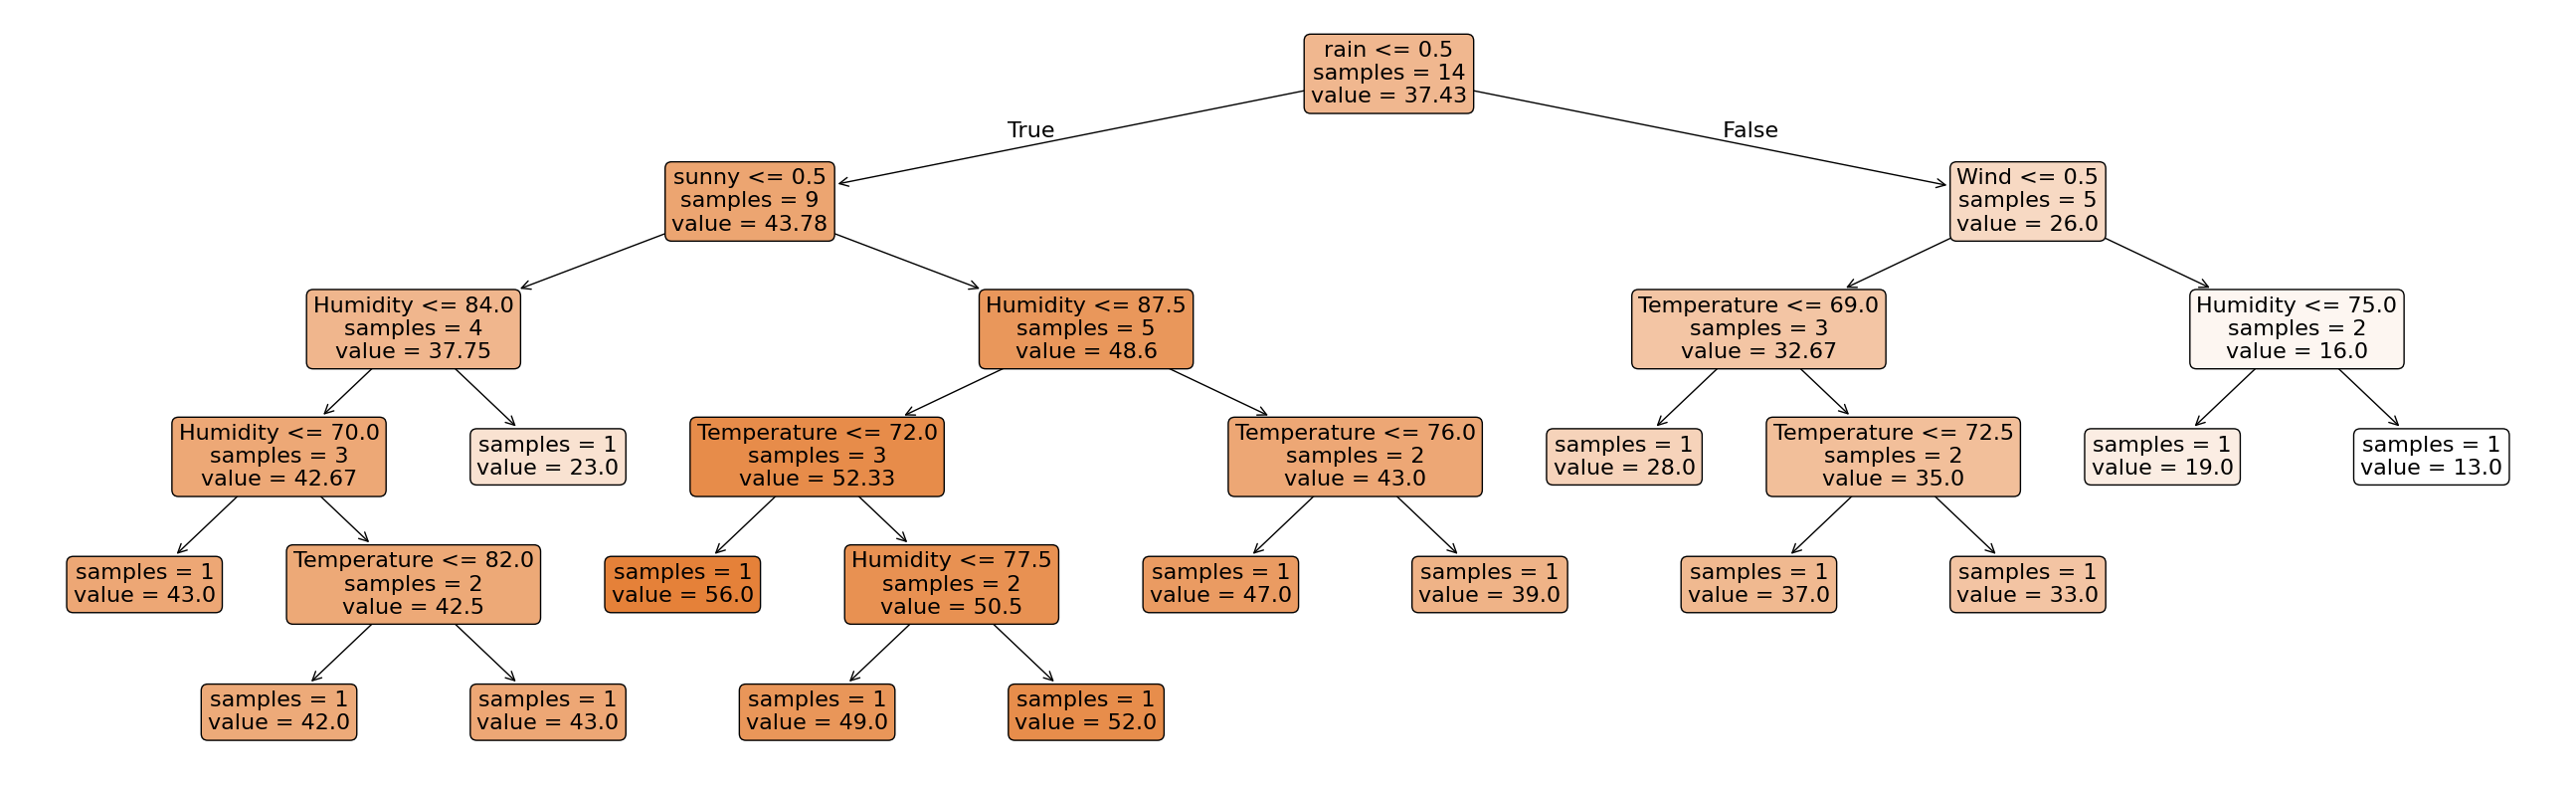

In [23]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train the model
regr = DecisionTreeRegressor(random_state=42)
regr.fit(X_train, y_train)

# Visualize the decision tree with impurity=False
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=False, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

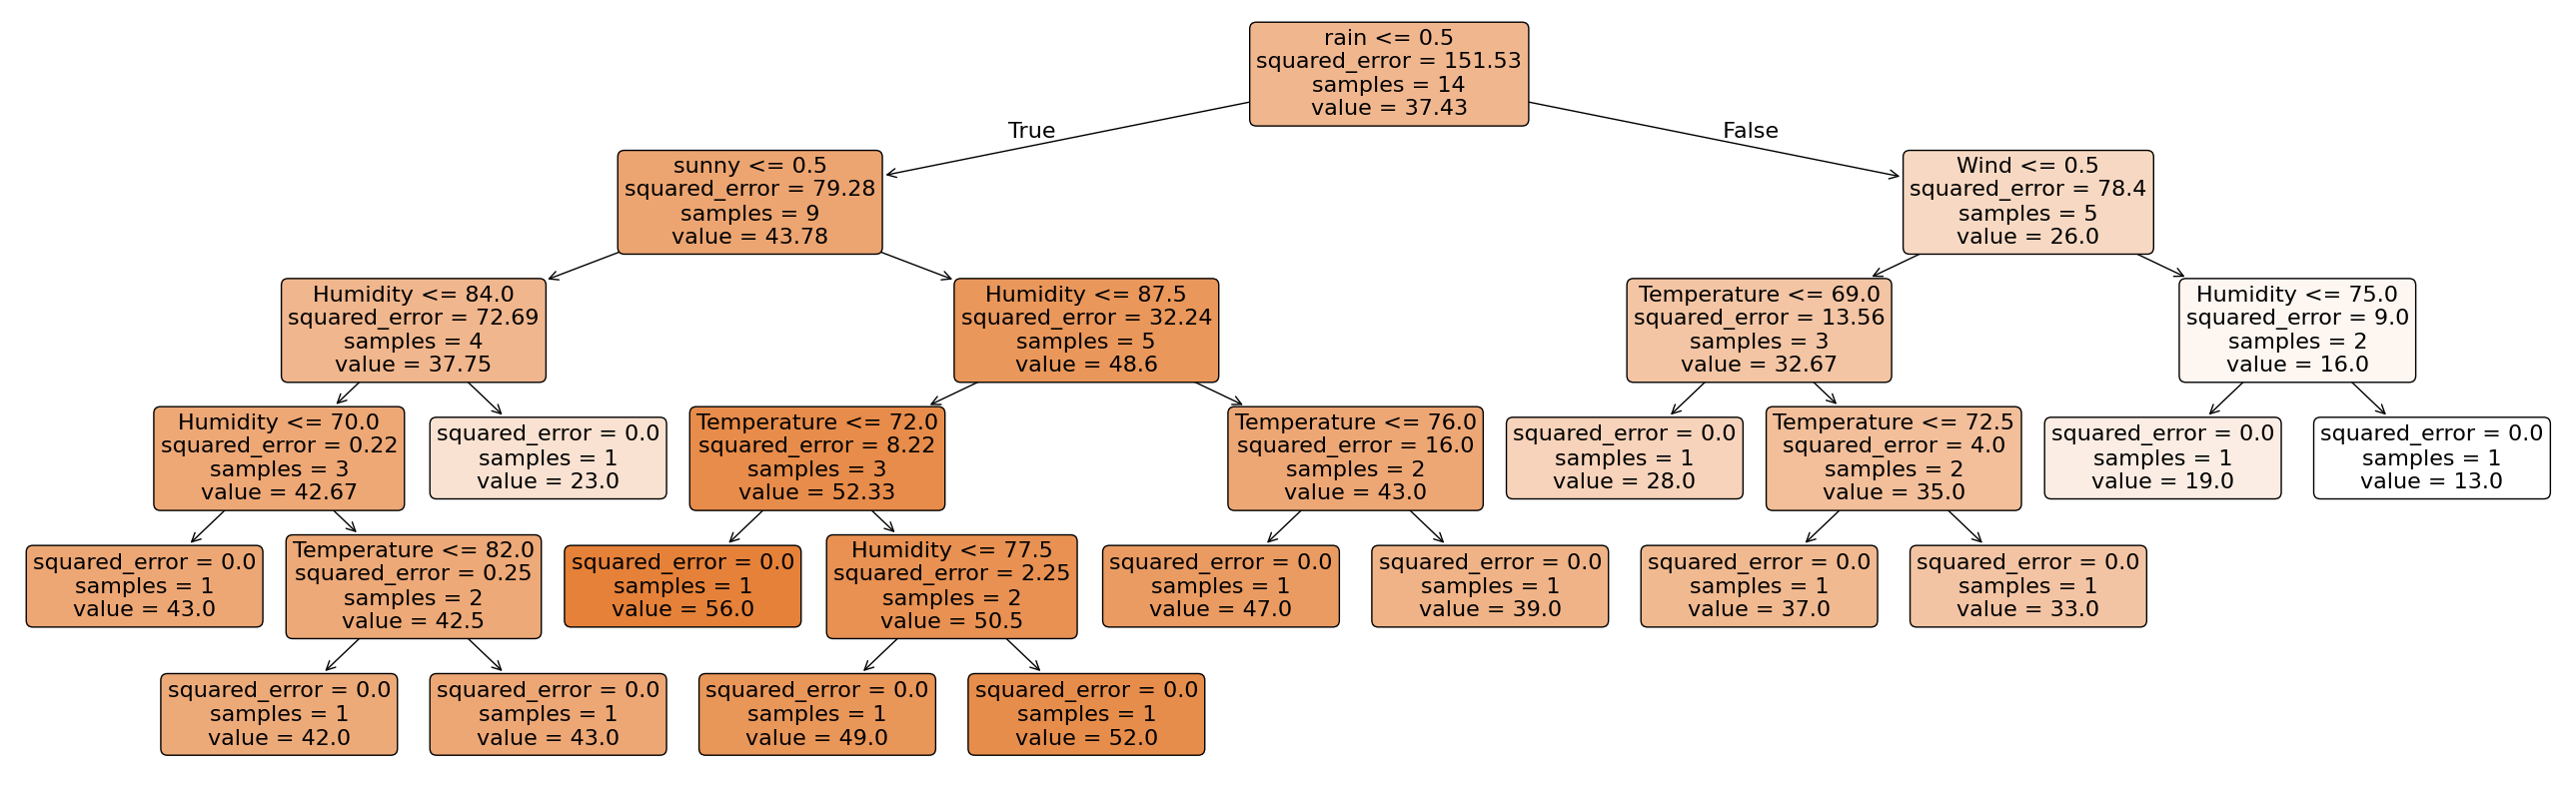

In [24]:
# Visualize the decision tree with impurity=True
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=True, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

In [25]:
# Final code with all steps...including cost complexties
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 
                'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 
                'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 
                    75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 
                    85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 
                 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 
                 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, 
             True, True, False, True, True, False, False, True, False, True, 
             True, False, True, False, False, True, False, False],
    'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 
                    49, 23, 42, 13, 33, 29, 25, 51, 41, 14, 
                    34, 29, 49, 36, 57, 21, 23, 41]
}

df = pd.DataFrame(dataset_dict)

# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Split data into features and target, then into training and test sets
X, y = df.drop(columns='Num_Players'), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Decision Tree Regressor
tree = DecisionTreeRegressor(random_state=42)

# Get the cost complexity path
path = tree.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Print ccp_alphas and impurities
print("CCP Alphas:", ccp_alphas)
print("Impurities:", impurities)

# Choose an optimal ccp_alpha (excluding the last one, which prunes the entire tree)
optimal_alpha = ccp_alphas[-2] if len(ccp_alphas) > 1 else 0.0

# Train the final tree with the selected alpha
final_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=optimal_alpha)
final_tree.fit(X_train_scaled, y_train)

# Make predictions
y_pred = final_tree.predict(X_test_scaled)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


CCP Alphas: [0.00000000e+00 2.38095238e-02 3.21428571e-01 5.71428571e-01
 1.28571429e+00 1.44047619e+00 2.28571429e+00 2.33333333e+00
 7.46666667e+00 1.97031746e+01 2.38095238e+01 7.25623583e+01]
Impurities: [0.00000000e+00 4.76190476e-02 3.69047619e-01 9.40476190e-01
 2.22619048e+00 3.66666667e+00 5.95238095e+00 8.28571429e+00
 1.57523810e+01 5.51587302e+01 7.89682540e+01 1.51530612e+02]
RMSE: 10.1495


In [26]:
# Compute the cost-complexity pruning path
tree = DecisionTreeRegressor(random_state=42)
effective_alphas = tree.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
impurities = tree.cost_complexity_pruning_path(X_train, y_train).impurities

# Function to count leaf nodes
count_leaves = lambda tree: sum(tree.tree_.children_left[i] == tree.tree_.children_right[i] == -1 for i in range(tree.tree_.node_count))

# Train trees and count leaves for each complexity parameter
leaf_counts = [count_leaves(DecisionTreeRegressor(random_state=0, ccp_alpha=alpha).fit(X_train_scaled, y_train)) for alpha in effective_alphas]

# Create DataFrame with analysis results
pruning_analysis = pd.DataFrame({
    'total_leaf_impurities': impurities,
    'leaf_count': leaf_counts,
    'cost_function': [f"{imp:.3f} + {leaves}α" for imp, leaves in zip(impurities, leaf_counts)],
    'effective_α': effective_alphas
})

print(pruning_analysis)

    total_leaf_impurities  leaf_count cost_function  effective_α
0                0.000000          14   0.000 + 14α     0.000000
1                0.047619          12   0.048 + 12α     0.023810
2                0.369048          11   0.369 + 11α     0.321429
3                0.940476          10   0.940 + 10α     0.571429
4                2.226190           9    2.226 + 9α     1.285714
5                3.666667           8    3.667 + 8α     1.440476
6                5.952381           7    5.952 + 7α     2.285714
7                8.285714           6    8.286 + 6α     2.333333
8               15.752381           5   15.752 + 5α     7.466667
9               55.158730           3   55.159 + 3α    19.703175
10              78.968254           2   78.968 + 2α    23.809524
11             151.530612           1  151.531 + 1α    72.562358
